## 1. Importar Bibliotecas e Carregar Dataset Preprocessado

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
import pickle
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, randint
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

Bibliotecas importadas com sucesso!
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1


In [2]:
# Carregamento e preparação inicial dos dados
print("Carregando datasets...")

# Carregar datasets pré-processados
train_data = pd.read_csv('SVHN_train_prep.csv')
test_data = pd.read_csv('SVHN_test_prep.csv')

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de teste: {test_data.shape}")

# Separar features e target
X_train = train_data.drop('digit', axis=1)
y_train = train_data['digit']
X_test = test_data.drop('digit', axis=1)
y_test = test_data['digit']

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDistribuição das classes:")
print("Treino:", y_train.value_counts().to_dict())
print("Teste:", y_test.value_counts().to_dict())

Carregando datasets...
Dataset de treino: (37233, 1825)
Dataset de teste: (12411, 1825)

Distribuição das classes:
Treino: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}
Teste: {1: 2430, 2: 1790, 3: 1408, 4: 1257, 5: 1203, 6: 995, 7: 912, 8: 815, 0: 813, 9: 788}


In [ ]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,1815,1816,1817,1818,1819,1820,1821,1822,1823,digit
0,0.132290,-0.078874,-0.007970,0.126206,-0.019496,0.049232,0.118899,-0.035883,0.027992,0.031445,...,1.514577,1.355709,1.418220,1.314246,1.393841,1.382280,1.272189,1.350409,1.342505,1
1,-1.261489,-1.223371,-1.000089,-1.225078,-1.232434,-0.959512,-1.124728,-1.226982,-0.848620,-1.207445,...,-1.251411,-1.451988,-1.167611,-1.313675,-1.466612,-1.229501,-1.268458,-1.301135,-1.067532,1
2,-0.803139,-0.742865,-0.624391,-0.887569,-0.834537,-0.721469,-0.968023,-0.922214,-0.717852,-0.951887,...,-1.567787,-1.773163,-1.590253,-1.399433,-1.590376,-1.392650,-1.309864,-1.443503,-1.416043,1
3,0.495477,0.708491,0.804662,0.502907,0.720904,0.816273,0.587815,0.800239,0.893713,0.593013,...,0.951751,0.926661,1.139622,0.921222,0.899732,1.112191,0.930080,0.907232,1.048508,2
4,0.731854,0.843948,0.588933,0.628960,0.746698,0.552313,0.452046,0.575681,0.506712,0.329009,...,0.918366,0.802927,0.817431,0.947489,0.807747,0.683944,0.860839,0.730585,0.559723,2


## 2. Sampling para Busca de Hiperparâmetros

In [ ]:
# ======================================================================
# SAMPLING ESTRATIFICADO PARA BUSCA DE HIPERPARÂMETROS
# ======================================================================

print("=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===")

# Dataset completo é muito grande para busca de hiperparâmetros
# Vamos usar uma amostra estratificada de 5% para otimização

# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=0.05,
    stratify=y_train,
    random_state=10
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", y_train.value_counts().to_dict())

=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===
Dataset original de treino: 37,233 amostras
Amostra para busca de hiperparâmetros: 1,862 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {1: 352, 2: 279, 3: 214, 4: 187, 5: 171, 7: 145, 6: 143, 0: 127, 8: 127, 9: 117}
Original: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}


## 3. Funções Auxiliares

In [15]:
# Função auxiliar para cálculo do G-Mean
def gmean_score(y_true, y_pred):
    """Calcula G-Mean para Multiclasse"""
    from sklearn.metrics import recall_score
    # Calcula recall de cada classe
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    # Média geométrica
    return np.prod(recalls) ** (1.0 / len(recalls))

# Função para avaliar modelos
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Avalia um modelo treinado e retorna métricas completas"""
    # Predições
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Métricas de treino
    train_metrics = {
        'accuracy_score': accuracy_score(y_train, y_train_pred),
        'precision': precision_score(y_train, y_train_pred, average='macro'),
        'recall': recall_score(y_train, y_train_pred, average='macro'),
        'f1': f1_score(y_train, y_train_pred, average='macro'),
        'gmean': gmean_score(y_train, y_train_pred)
    }

    # Métricas de teste
    test_metrics = {
        'accuracy_score': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred, average='macro'),
        'recall': recall_score(y_test, y_test_pred, average='macro'),
        'f1': f1_score(y_test, y_test_pred, average='macro'),
        'gmean': gmean_score(y_test, y_test_pred)
    }

    # AUC se o modelo suporta predict_proba
    try:
        y_test_proba = model.predict_proba(X_test)[:, 1]
        test_metrics['auc_roc'] = roc_auc_score(y_test, y_test_proba)
    except:
        test_metrics['auc_roc'] = None

    return train_metrics, test_metrics, y_test_pred

# Função para plotar histórico de busca
def plot_search_history(search_results, model_name, metric='mean_test_score'):
    """Plota a evolução dos resultados durante a busca de hiperparâmetros"""
    plt.figure(figsize=(12, 6))

    results_df = pd.DataFrame(search_results.cv_results_)

    plt.subplot(1, 2, 1)
    plt.plot(results_df[metric], 'b-o', alpha=0.7)
    plt.fill_between(range(len(results_df)),
                     results_df[metric] - results_df['std_test_score'],
                     results_df[metric] + results_df['std_test_score'],
                     alpha=0.3)
    plt.title(f'{model_name} - Evolução do F1-Score')
    plt.xlabel('Iteração')
    plt.ylabel('F1-Score (CV)')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    # Verificar se existe coluna de treino
    if 'mean_train_score' in results_df.columns:
        plt.plot(results_df['mean_train_score'], 'g-o', alpha=0.7, label='Treino')
    plt.plot(results_df[metric], 'b-o', alpha=0.7, label='Validação')
    plt.title(f'{model_name} - Treino vs Validação')
    plt.xlabel('Iteração')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Função para executar múltiplas buscas de hiperparâmetros
def multiple_randomized_search(estimator, param_distributions, X, y, cv_strategy,
                              n_searches=20, n_iter_per_search=80, scoring='f1_macro',
                              random_state=42, n_jobs=-1, verbose=0):
    """
    Executa múltiplas buscas RandomizedSearchCV e retorna a melhor configuração global

    Parameters:
    -----------
    n_searches : int
        Número de execuções do RandomizedSearchCV (default: 20)
    n_iter_per_search : int
        Número de iterações por execução (default: 80)
    """
    print(f"Executando {n_searches} buscas com {n_iter_per_search} iterações cada...")

    best_overall_score = -np.inf
    best_overall_params = None
    best_search_result = None
    all_results = []

    for search_idx in range(n_searches):
        print(f"\nBusca {search_idx + 1}/{n_searches}...")

        # RandomizedSearchCV para esta execução
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_distributions,
            n_iter=n_iter_per_search,
            scoring=scoring,
            cv=cv_strategy,
            random_state=None,
            n_jobs=n_jobs,
            return_train_score=True,
            verbose=0  # Menos verbose para múltiplas execuções
        )

        search.fit(X, y)

        # Armazenar resultados desta busca
        search_results = {
            'search_idx': search_idx,
            'best_score': search.best_score_,
            'best_params': search.best_params_,
            'cv_results': search.cv_results_
        }
        all_results.append(search_results)

        # Verificar se esta é a melhor busca até agora
        if search.best_score_ > best_overall_score:
            best_overall_score = search.best_score_
            best_overall_params = search.best_params_
            best_search_result = search

        print(f"Melhor score desta busca: {search.best_score_:.4f}")
        print(f"Melhor score geral até agora: {best_overall_score:.4f}")

    print(f"\n🎯 Busca completa! Melhor score geral: {best_overall_score:.4f}")
    print(f"Total de configurações testadas: {n_searches * n_iter_per_search:,}")

    return best_search_result, all_results, best_overall_params

print("Funções auxiliares definidas com sucesso!")

Funções auxiliares definidas com sucesso!


## 3.1 Definir Folds

In [ ]:
# Configuração da validação cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 4. Decision Tree - Busca de Hiperparâmetros

In [13]:
# Definir nome do modelo para uso em salvamento e exibição. Necessário Rodar essa célula antes de outras.
MODEL_NAME = "DT"

In [ ]:
# ======================================================================
# 4.1 BUSCA DE HIPERPARAMETROS
# ======================================================================

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")


# 4.3 Definição do Espaço de Hiperparâmetros
param_distributions = {
    'max_depth': randint(3, 50),                    # Profundidade máxima
    'min_samples_split': randint(2, 40),            # Mínimo de amostras para dividir
    'min_samples_leaf': randint(1, 50),             # Mínimo de amostras por folha
    'criterion': ['gini', 'entropy'],               # Critério de divisão
    'max_features': ['sqrt', 'log2', None]          # Número máximo de features
}


# 4.1 Múltiplas execuções do RandomizedSearchCV
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
model_search, model_all_searches, best_params = multiple_randomized_search(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_distributions,
    X=X_sample,
    y=y_sample,
    cv_strategy=cv_strategy,
    n_searches=20,
    n_iter_per_search=40,
    scoring='f1_macro',
    n_jobs=-1
)

# 5.1 Seleção da Melhor Configuração
print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nMelhor F1-Score (CV): {model_search.best_score_:.4f}")

=== BUSCA DE HIPERPARÂMETROS - DT ===
Iniciando busca de hiperparâmetros para DT...
Executando 20 buscas com 40 iterações cada...

Busca 1/20...
Melhor score desta busca: 0.3584
Melhor score geral até agora: 0.3584

Busca 2/20...
Melhor score desta busca: 0.3125
Melhor score geral até agora: 0.3584

Busca 3/20...
Melhor score desta busca: 0.3685
Melhor score geral até agora: 0.3685

Busca 4/20...
Melhor score desta busca: 0.3522
Melhor score geral até agora: 0.3685

Busca 5/20...
Melhor score desta busca: 0.3591
Melhor score geral até agora: 0.3685

Busca 6/20...
Melhor score desta busca: 0.3633
Melhor score geral até agora: 0.3685

Busca 7/20...
Melhor score desta busca: 0.3546
Melhor score geral até agora: 0.3685

Busca 8/20...
Melhor score desta busca: 0.3635
Melhor score geral até agora: 0.3685

Busca 9/20...
Melhor score desta busca: 0.3591
Melhor score geral até agora: 0.3685

Busca 10/20...
Melhor score desta busca: 0.3553
Melhor score geral até agora: 0.3685

Busca 11/20...
Mel

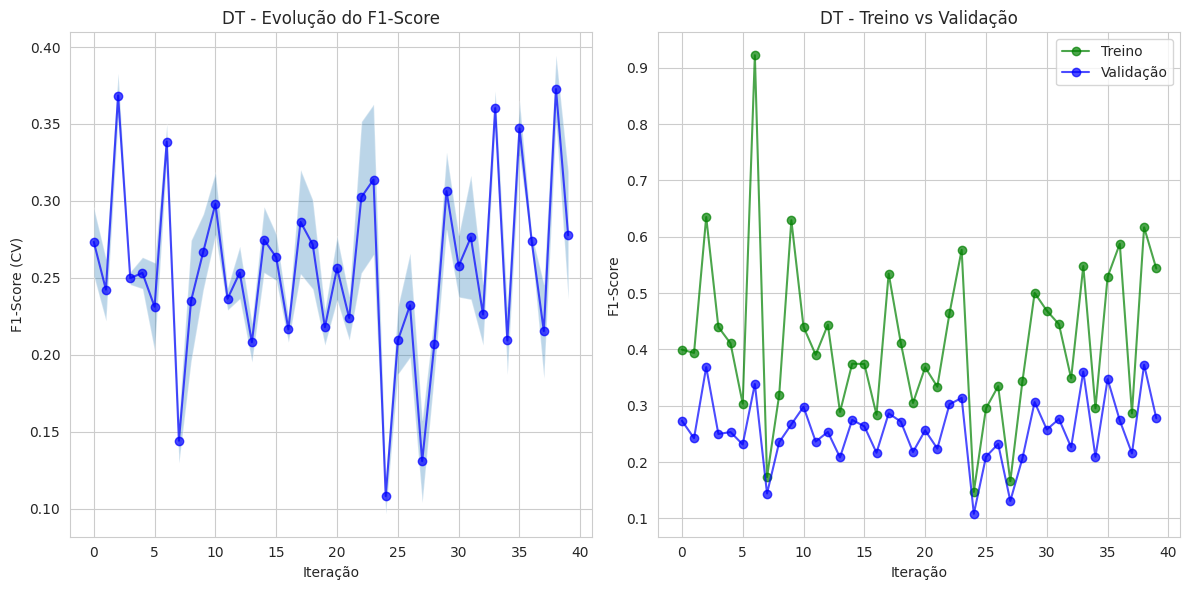

In [ ]:
# 4.4 Registro de Desempenho - plotar evolução
plot_search_history(model_search, MODEL_NAME)

## 5. Salvar Resultados de Busca
Seção serve somente para salvar o resultado de toda a busca num CSV e os dados essenciais no JSON.

Usar se quiser manter os resultados guardados num diretório por garantia.

In [ ]:
## 4.1 Salvar Resultados da Busca de Hiperparâmetros

print(f"=== SALVANDO RESULTADOS DA BUSCA - {MODEL_NAME} ===")

# Criar pasta se não existir
os.makedirs('searches', exist_ok=True)

# 1. Salvar resultados detalhados de todas as buscas
search_detailed_results = []

for i, search_result in enumerate(model_all_searches):
    # Extrair informações de cada busca individual
    cv_results = search_result['cv_results']

    for j in range(len(cv_results['mean_test_score'])):
        search_detailed_results.append({
            'search_idx': search_result['search_idx'],
            'iteration': j,
            'mean_test_score': cv_results['mean_test_score'][j],
            'std_test_score': cv_results['std_test_score'][j],
            'mean_train_score': cv_results['mean_train_score'][j] if 'mean_train_score' in cv_results else None,
            'std_train_score': cv_results['std_train_score'][j] if 'std_train_score' in cv_results else None,
            'params': str(cv_results['params'][j]),
            **cv_results['params'][j]  # Expandir parâmetros como colunas separadas
        })

# Converter para DataFrame e salvar
search_df = pd.DataFrame(search_detailed_results)
search_df.to_csv(f'searches/{MODEL_NAME.lower()}_all_searches.csv', index=False)

print(f"  Todos os Resultados salvos: searches/{MODEL_NAME.lower()}_all_searches.csv")
print(f"  Total de configurações testadas: {len(search_df):,}")

# 2. Salvar resumo da melhor busca
param_space_serializable = {k: str(v) for k, v in param_distributions.items()}

best_search_summary = {
    'model_name': MODEL_NAME,
    'best_overall_score': float(model_search.best_score_), # Convertendo para float nativo do Python para garantir
    'best_overall_params': model_search.best_params_,
    'search_config': {
        'n_searches': 20,
        'n_iter_per_search': 40,
        'scoring': 'f1',
        'cv_folds': 5,
        'total_configurations': len(search_df)
    },
    'param_space': param_space_serializable,  # <--- USAR A VERSÃO CONVERTIDA AQUI
    'top_10_configs': search_df.nlargest(10, 'mean_test_score')[
        ['mean_test_score', 'std_test_score'] + list(best_params.keys())
    ].to_dict('records')
}

# Salvar resumo em JSON
with open(f'searches/{MODEL_NAME.lower()}_search_summary.json', 'w') as f:
    json.dump(best_search_summary, f, indent=2)

print(f"  Dados necessários para as seções seguintes: searches/{MODEL_NAME.lower()}_search_summary.json")

# Mostrar estatísticas da busca
print(f"\n--- ESTATÍSTICAS DA BUSCA {MODEL_NAME} ---")
print(f"Melhor F1-Score: {model_search.best_score_:.4f}")
print(f"Desvio padrão do melhor: {search_df.loc[search_df['mean_test_score'].idxmax(), 'std_test_score']:.4f}")
print(f"F1-Score médio geral: {search_df['mean_test_score'].mean():.4f}")
print(f"F1-Score mínimo: {search_df['mean_test_score'].min():.4f}")
print(f"F1-Score máximo: {search_df['mean_test_score'].max():.4f}")

=== SALVANDO RESULTADOS DA BUSCA - DT ===
  Todos os Resultados salvos: searches/dt_all_searches.csv
  Total de configurações testadas: 800
  Dados necessários para as seções seguintes: searches/dt_search_summary.json

--- ESTATÍSTICAS DA BUSCA DT ---
Melhor F1-Score: 0.3727
Desvio padrão do melhor: 0.0220
F1-Score médio geral: 0.2488
F1-Score mínimo: 0.0945
F1-Score máximo: 0.3727


## 6. Carregar Resultados de Busca
Não precisa rodar caso a busca tenha acabado de ser feita. Rode somente se recuperar resultados salvos.  

In [3]:
def load_search_results(model_name, searches_folder='searches'):
    """
    Carrega resultados de busca salvos anteriormente

    Returns:
    --------
    dict: Dicionário com todos os resultados carregados
    """
    print(f"=== CARREGANDO RESULTADOS DE BUSCA - {model_name.upper()} ===")

    results = {}

    # 1. Carregar DataFrame detalhado
    csv_path = os.path.join(searches_folder, f'{model_name.lower()}_all_searches.csv')
    if os.path.exists(csv_path):
        results['detailed_df'] = pd.read_csv(csv_path)
        print(f"✅ Resultados detalhados carregados: {len(results['detailed_df']):,} configurações")
    else:
        print(f"⚠️  Arquivo não encontrado: {csv_path}")

    # 2. Carregar resumo JSON
    json_path = os.path.join(searches_folder, f'{model_name.lower()}_search_summary.json')
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            results['summary'] = json.load(f)
        print(f"✅ Resumo carregado: F1-Score = {results['summary']['best_overall_score']:.4f}")
    else:
        print(f"⚠️  Arquivo não encontrado: {json_path}")

    # 3. Carregar backup pickle
    pkl_path = os.path.join(searches_folder, f'{model_name.lower()}_full_search.pkl')
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            results['full_backup'] = pickle.load(f)
        print(f"✅ Backup completo carregado")
    else:
        print(f"⚠️  Arquivo não encontrado: {pkl_path}")

    return results


def get_best_params_from_saved(model_name, searches_folder='searches'):
    """
    Recupera os melhores parâmetros de arquivos salvos

    Returns:
    --------
    dict: Melhores parâmetros encontrados
    """
    # Tentar carregar do JSON primeiro
    json_path = os.path.join(searches_folder, f'{model_name.lower()}_search_summary.json')

    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            summary = json.load(f)
        return summary['best_overall_params']

    # Fallback para pickle
    pkl_path = os.path.join(searches_folder, f'{model_name.lower()}_full_search.pkl')
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            backup = pickle.load(f)
        return backup['best_params']

    print(f"❌ Não foi possível carregar parâmetros para {model_name}")
    return None


In [6]:
#### 4.2 Carregar Resultados Salvos (Função Auxiliar)
# Exemplo de uso da função (não executar se já temos os resultados)
# loaded_results = load_search_results(MODEL_NAME)


#### 4.3 Recuperar Melhores Parâmetros para Uso Posterior
# Exemplo de uso (descomente se precisar carregar parâmetros salvos):
# if 'best_params' not in locals():
#     best_params = get_best_params_from_saved(MODEL_NAME)
#     if best_params:
#         print(f"✅ Parâmetros carregados: {best_params}")

In [7]:
import json
from sklearn.tree import DecisionTreeClassifier

# 1. Carregar os melhores parâmetros do arquivo salvo
try:
    with open('searches/dt_search_summary.json', 'r') as f:
        summary = json.load(f)

    best_params = summary['best_overall_params']
    best_cv_score = summary['best_overall_score']

    print("✅ Parâmetros recuperados com sucesso!")
    print(f"Melhores Parâmetros: {best_params}")
    print(f"Melhor Score (CV): {best_cv_score}")

    # 2. Recriar o objeto best_model manualmente
    # Nota: random_state=42 é importante para reproduzir a árvore exata
    best_model = DecisionTreeClassifier(random_state=42, **best_params)

except FileNotFoundError:
    print("Arquivo 'searches/dt_search_summary.json' não encontrado.")
    print("Verifique se a pasta 'searches' ainda está na aba de arquivos à esquerda.")

✅ Parâmetros recuperados com sucesso!
Melhores Parâmetros: {'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 11, 'min_samples_split': 22}
Melhor Score (CV): 0.372694026687871


## 7. Treinar Modelo Final e Salvar como Joblib

In [11]:
# 5.2 Treinamento Final com dataset completo usando melhores hiperparâmetros

best_model = DecisionTreeClassifier(random_state=42, **best_params)

# Armazenar resultados

model_results = {
    'model': best_model,
    'best_params': best_params,
    'best_cv_score': best_cv_score
}

In [ ]:


best_model.fit(X_train_scaled, y_train)  # Treino
print(f"\nModelo final {MODEL_NAME} treinado com dataset completo: {best_model}")


Modelo final DT treinado com dataset completo: DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=11,
                       min_samples_split=22, random_state=42)


In [16]:
# Salvar modelo treinado
dump(best_model, f'models/{MODEL_NAME.lower()}_trained.joblib')

['models/dt_trained.joblib']

## 8. Carregar Modelo, Avaliar and Salvar Resultados

### 8.1 Carregar Modelo

In [17]:
# Carregar modelo
loaded_model = load(f'models/{MODEL_NAME.lower()}_trained.joblib')

### 8.2 Avaliação

In [ ]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# 2. Avaliação completa do modelo (usando amostras para economizar tempo)
print("\nAvaliando performance do modelo...")

try:
    model = best_model
except NameError:
    model = loaded_model


X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test


# Avaliar modelo
train_metrics, test_metrics, y_pred = evaluate_model(
    model, X_train_eval, X_test_eval, y_train_eval, y_test_eval, MODEL_NAME
)

# 3. Compilar todos os resultados
model_final_results = {
    'model_name': MODEL_NAME,
    'best_params': best_params,
    'best_cv_score': best_cv_score,
    'train_metrics': train_metrics,
    'test_metrics': test_metrics,
    'predictions': y_pred.tolist(), # Converter para lista no JSON
    'test_labels': y_test_eval.tolist(),
    'evaluation_info': {
        'train_samples_used': len(X_train_eval),
        'test_samples_used': len(X_test_eval),
        'total_train_samples': len(X_train_scaled),
        'total_test_samples': len(X_test_scaled)
    }
}

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - DT ===

Avaliando performance do modelo...


### 8.3 Salvar Métricas para Plotagem

In [22]:
with open(f'results/{MODEL_NAME.lower()}_results.json', 'w') as f:
    json.dump(model_final_results, f, indent=2)

print(f"Resultados {MODEL_NAME} salvos em: results/{MODEL_NAME.lower()}_results.json")

Resultados DT salvos em: results/dt_results.json


In [23]:
# ================
# Rode se quiser salvar um backup em pickle também ou caso anterior JSON falhe
# ================

with open(f'results/{MODEL_NAME.lower()}_results.pkl', 'wb') as f:
    pickle.dump(model_final_results, f)

print(f"Backup dos resultados salvo em: results/{MODEL_NAME.lower()}_results.pkl")

# Mostrar resumo para verificação rápida
print(f"\n--- RESUMO {MODEL_NAME} ---")
print(f"F1-Score CV: {model_final_results['best_cv_score']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")
print(f"G-Mean Teste: {test_metrics['gmean']:.4f}")

Backup dos resultados salvo em: results/dt_results.pkl

--- RESUMO DT ---
F1-Score CV: 0.3727
F1-Score Teste: 0.5034
Precisão Teste: 0.5264
Recall Teste: 0.4927
G-Mean Teste: 0.4784
